<a href="https://colab.research.google.com/github/balrajparsi/balrajparsi/blob/main/Assignment9_MusicTransformer_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 9: Music-Generating Transformer

**Course:** Generative AI with Large Language Models  
**Reference:** Chapter 11 - *Generative Deep Learning* (2nd Ed.), David Foster  
**Compatibility:** TF 2.19 / Keras 3.x / Google Colab A100 GPU

## 1. Install and Setup

In [1]:
!pip install -q music21

import os
import glob
import math
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import music21
from tensorflow.keras import layers, models, losses, callbacks, optimizers

warnings.filterwarnings(
    "ignore",
    message="You are using a softmax over axis 3 of a tensor of shape"
)

print(f"TF: {tf.__version__}, Keras: {keras.__version__}")
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU: {gpus[0].name}")
else:
    print("No GPU detected. In Colab, switch Runtime > Change runtime type > GPU.")

for d in ["./output", "./checkpoint", "./models", "./bach-cello"]:
    os.makedirs(d, exist_ok=True)

print("Setup complete.")

TF: 2.19.0, Keras: 3.13.2
GPU: /physical_device:GPU:0
Setup complete.


## 2. Parameters

In [2]:
SEQ_LEN = 50
EMBEDDING_DIM = 256
KEY_DIM = 64
N_HEADS = 4
DROPOUT_RATE = 0.2
FEED_FORWARD_DIM = 512
BATCH_SIZE = 64
EPOCHS = 300
GENERATE_LEN = 50
LEARNING_RATE = 1e-3
LOAD_MODEL = False

CHECKPOINT_PATH = "./checkpoint/music_transformer.weights.h5"
MODEL_PATH = "./models/music_transformer.keras"

## 3. Download Bach Cello Suite MIDI Files

In [4]:
# ============================================================
# Download Bach Cello Suite MIDI files
# ============================================================

import os, glob, urllib.request

os.makedirs("./bach-cello", exist_ok=True)

BACH_FILES = [
    "cs1-1pre.mid", "cs1-2all.mid", "cs1-3cou.mid", "cs1-4sar.mid", "cs1-5men.mid", "cs1-6gig.mid",
    "cs2-1pre.mid", "cs2-2all.mid", "cs2-3cou.mid", "cs2-4sar.mid", "cs2-5men.mid", "cs2-6gig.mid",
    "cs3-1pre.mid", "cs3-2all.mid", "cs3-3cou.mid", "cs3-4sar.mid", "cs3-5bou.mid", "cs3-6gig.mid",
    "cs4-1pre.mid", "cs4-2all.mid", "cs4-3cou.mid", "cs4-4sar.mid", "cs4-5bou.mid", "cs4-6gig.mid",
    "cs5-1pre.mid", "cs5-2all.mid", "cs5-3cou.mid", "cs5-4sar.mid", "cs5-5gav.mid", "cs5-6gig.mid",
    "cs6-1pre.mid", "cs6-2all.mid", "cs6-3cou.mid", "cs6-4sar.mid", "cs6-5gav.mid", "cs6-6gig.mid",
]

BASE_URL = "http://www.jsbach.net/midi/"

file_list = sorted(glob.glob("./bach-cello/*.mid"))
print(f"Found {len(file_list)} MIDI files before download.")

missing = [name for name in BACH_FILES if not os.path.exists(os.path.join("./bach-cello", name))]
print(f"Missing {len(missing)} files.")

for name in missing:
    url = BASE_URL + name
    target_path = os.path.join("./bach-cello", name)
    try:
        urllib.request.urlretrieve(url, target_path)
        print(f"Downloaded: {name}")
    except Exception as e:
        print(f"Download failed for {name}: {e}")

file_list = sorted(glob.glob("./bach-cello/*.mid"))
print(f"Found {len(file_list)} MIDI files after download attempt.")

if len(file_list) == 0:
    raise FileNotFoundError(
        "No Bach MIDI files were downloaded. If Colab blocks http://www.jsbach.net/midi/, "
        "manually download the cello-suite MIDIs and upload them into ./bach-cello."
    )

print("First five files:")
for f in file_list[:5]:
    print(" ", f)

Found 0 MIDI files before download.
Missing 36 files.
Downloaded: cs1-1pre.mid
Downloaded: cs1-2all.mid
Downloaded: cs1-3cou.mid
Downloaded: cs1-4sar.mid
Downloaded: cs1-5men.mid
Downloaded: cs1-6gig.mid
Downloaded: cs2-1pre.mid
Downloaded: cs2-2all.mid
Downloaded: cs2-3cou.mid
Downloaded: cs2-4sar.mid
Downloaded: cs2-5men.mid
Downloaded: cs2-6gig.mid
Downloaded: cs3-1pre.mid
Downloaded: cs3-2all.mid
Downloaded: cs3-3cou.mid
Downloaded: cs3-4sar.mid
Downloaded: cs3-5bou.mid
Downloaded: cs3-6gig.mid
Downloaded: cs4-1pre.mid
Downloaded: cs4-2all.mid
Downloaded: cs4-3cou.mid
Downloaded: cs4-4sar.mid
Downloaded: cs4-5bou.mid
Downloaded: cs4-6gig.mid
Downloaded: cs5-1pre.mid
Downloaded: cs5-2all.mid
Downloaded: cs5-3cou.mid
Downloaded: cs5-4sar.mid
Downloaded: cs5-5gav.mid
Downloaded: cs5-6gig.mid
Downloaded: cs6-1pre.mid
Downloaded: cs6-2all.mid
Downloaded: cs6-3cou.mid
Downloaded: cs6-4sar.mid
Downloaded: cs6-5gav.mid
Downloaded: cs6-6gig.mid
Found 36 MIDI files after download attempt.
Fi

## 4. Parse MIDI Files

Extract note pitches and durations from each MIDI file using music21.

In [5]:
def normalize_duration_token(value):
    value = round(float(value), 3)
    text = f"{value:.3f}".rstrip("0").rstrip(".")
    if "." not in text:
        text += ".0"
    return text


def get_midi_note(sample_note, sample_duration):
    """Convert note/duration strings into music21 objects."""
    if sample_note == "START":
        return None

    new_note = None

    if sample_note == "rest":
        new_note = music21.note.Rest()
    elif "." in sample_note and not sample_note.replace(".", "").isdigit():
        chord_notes = []
        for token in sample_note.split("."):
            try:
                chord_notes.append(music21.note.Note(token))
            except Exception:
                return None
        new_note = music21.chord.Chord(chord_notes)
    elif sample_note != "":
        try:
            new_note = music21.note.Note(sample_note)
        except Exception:
            return None

    if new_note is not None:
        try:
            new_note.duration = music21.duration.Duration(float(sample_duration))
        except Exception:
            new_note.duration = music21.duration.Duration(0.5)

    return new_note


def extract_note_and_duration_tokens(file_path):
    score = music21.converter.parse(file_path)
    stream_source = score.parts[0] if len(score.parts) > 0 else score

    note_tokens = ["START"]
    duration_tokens = ["0.0"]

    for element in stream_source.flatten().notesAndRests:
        if isinstance(element, music21.note.Note):
            note_tokens.append(element.pitch.nameWithOctave)
        elif isinstance(element, music21.chord.Chord):
            note_tokens.append(".".join(p.nameWithOctave for p in element.pitches))
        elif isinstance(element, music21.note.Rest):
            note_tokens.append("rest")
        else:
            continue

        duration_tokens.append(normalize_duration_token(element.duration.quarterLength))

    return note_tokens, duration_tokens


def parse_midi_files(file_list, seq_len):
    notes_out = []
    durations_out = []
    lengths = []

    for i, file_path in enumerate(file_list, start=1):
        try:
            note_tokens, duration_tokens = extract_note_and_duration_tokens(file_path)
        except Exception as e:
            print(f"Skipped {file_path}: {e}")
            continue

        lengths.append(len(note_tokens))
        print(f"Parsed {i:02d}/{len(file_list)} | {os.path.basename(file_path)} | tokens={len(note_tokens)}")

        if len(note_tokens) <= seq_len:
            continue

        for start in range(0, len(note_tokens) - seq_len):
            notes_out.append(" ".join(note_tokens[start:start + seq_len + 1]))
            durations_out.append(" ".join(duration_tokens[start:start + seq_len + 1]))

    print(f"\nFiles parsed successfully: {len(lengths)}")
    if lengths:
        print(f"Token count per file | min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}")
    print(f"Total training sequences: {len(notes_out)}")

    if len(notes_out) == 0:
        raise ValueError(
            "Zero training sequences were created. That means the MIDI parse step failed or the dataset is missing. "
            "Do not continue until this is fixed."
        )

    return notes_out, durations_out


notes, durations = parse_midi_files(file_list, SEQ_LEN)

print("\nExample note sequence:")
print(notes[0][:180] + "...")
print("\nExample duration sequence:")
print(durations[0][:180] + "...")

Parsed 01/36 | cs1-1pre.mid | tokens=655
Parsed 02/36 | cs1-2all.mid | tokens=918
Parsed 03/36 | cs1-3cou.mid | tokens=818
Parsed 04/36 | cs1-4sar.mid | tokens=253
Parsed 05/36 | cs1-5men.mid | tokens=643
Parsed 06/36 | cs1-6gig.mid | tokens=423
Parsed 07/36 | cs2-1pre.mid | tokens=636
Parsed 08/36 | cs2-2all.mid | tokens=675
Parsed 09/36 | cs2-3cou.mid | tokens=597
Parsed 10/36 | cs2-4sar.mid | tokens=329
Parsed 11/36 | cs2-5men.mid | tokens=496
Parsed 12/36 | cs2-6gig.mid | tokens=701
Parsed 13/36 | cs3-1pre.mid | tokens=940
Parsed 14/36 | cs3-2all.mid | tokens=736
Parsed 15/36 | cs3-3cou.mid | tokens=987
Parsed 16/36 | cs3-4sar.mid | tokens=219
Parsed 17/36 | cs3-5bou.mid | tokens=877
Parsed 18/36 | cs3-6gig.mid | tokens=793
Parsed 19/36 | cs4-1pre.mid | tokens=795
Parsed 20/36 | cs4-2all.mid | tokens=1049
Parsed 21/36 | cs4-3cou.mid | tokens=908
Parsed 22/36 | cs4-4sar.mid | tokens=200
Parsed 23/36 | cs4-5bou.mid | tokens=1306
Parsed 24/36 | cs4-6gig.mid | tokens=969
Parsed 25/36 |

## 5. Tokenize and Build Training Dataset

**Critical:** All data is forced to `tf.string` dtype to prevent TensorFlow
from auto-casting numeric-looking duration strings (like '0.0 1.0') to floats.

In [6]:
# ============================================================
# Tokenization and dataset creation
# ============================================================

notes_tensor = tf.constant(notes, dtype=tf.string)
durations_tensor = tf.constant(durations, dtype=tf.string)

print(f"notes_tensor dtype: {notes_tensor.dtype}")
print(f"durations_tensor dtype: {durations_tensor.dtype}")

notes_vectorize_layer = layers.TextVectorization(
    standardize=None,
    split="whitespace",
    output_mode="int"
)
durations_vectorize_layer = layers.TextVectorization(
    standardize=None,
    split="whitespace",
    output_mode="int"
)

notes_vectorize_layer.adapt(tf.data.Dataset.from_tensor_slices(notes_tensor).batch(256))
durations_vectorize_layer.adapt(tf.data.Dataset.from_tensor_slices(durations_tensor).batch(256))

notes_vocab = notes_vectorize_layer.get_vocabulary()
durations_vocab = durations_vectorize_layer.get_vocabulary()

notes_vocab_size = len(notes_vocab)
durations_vocab_size = len(durations_vocab)

print(f"\nNotes vocab size: {notes_vocab_size}")
print(f"Durations vocab size: {durations_vocab_size}")
print(f"First 20 notes: {notes_vocab[:20]}")
print(f"First 20 durations: {durations_vocab[:20]}")

if notes_vocab_size <= 2 or durations_vocab_size <= 2:
    raise ValueError(
        "Vocabulary collapsed to only ['', '[UNK]']. This always means the training sequences are empty or invalid."
    )

tokenized_notes = notes_vectorize_layer(notes_tensor).numpy()
tokenized_durations = durations_vectorize_layer(durations_tensor).numpy()

x_notes = tokenized_notes[:, :-1].astype("int32")
y_notes = tokenized_notes[:, 1:].astype("int32")
x_durations = tokenized_durations[:, :-1].astype("int32")
y_durations = tokenized_durations[:, 1:].astype("int32")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = (
    tf.data.Dataset.from_tensor_slices(((x_notes, x_durations), (y_notes, y_durations)))
    .shuffle(len(x_notes))
    .batch(BATCH_SIZE, drop_remainder=False)
    .prefetch(AUTOTUNE)
)

STEPS_PER_EPOCH = math.ceil(len(x_notes) / BATCH_SIZE)

print(f"\nSamples: {len(x_notes)}")
print(f"Input note shape: {x_notes.shape}")
print(f"Input duration shape: {x_durations.shape}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Steps per epoch: {STEPS_PER_EPOCH}")
print("Training dataset ready.")

notes_tensor dtype: <dtype: 'string'>
durations_tensor dtype: <dtype: 'string'>

Notes vocab size: 237
Durations vocab size: 29
First 20 notes: ['', '[UNK]', np.str_('G3'), np.str_('A3'), np.str_('D3'), np.str_('F3'), np.str_('E3'), np.str_('C4'), np.str_('D4'), np.str_('B3'), np.str_('F#3'), np.str_('E-3'), np.str_('B-3'), np.str_('C3'), np.str_('rest'), np.str_('G#3'), np.str_('G2'), np.str_('E4'), np.str_('C#4'), np.str_('B2')]
First 20 durations: ['', '[UNK]', np.str_('0.25'), np.str_('0.5'), np.str_('1.0'), np.str_('0.333'), np.str_('0.75'), np.str_('1.5'), np.str_('2.0'), np.str_('3.0'), np.str_('0.083'), np.str_('1.25'), np.str_('4.0'), np.str_('1.333'), np.str_('2.5'), np.str_('0.167'), np.str_('1.75'), np.str_('3.75'), np.str_('6.0'), np.str_('2.75')]

Samples: 24181
Input note shape: (24181, 50)
Input duration shape: (24181, 50)
Batch size: 64
Steps per epoch: 378
Training dataset ready.


## 6. Custom Layers: SinePositionEncoding, TransformerBlock, Embeddings

In [7]:
# ============================================================
# Sine Position Encoding (replaces keras_nlp dependency)
# ============================================================
class SinePositionEncoding(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        seq_length = tf.shape(inputs)[1]
        d_model = tf.shape(inputs)[2]
        positions = tf.cast(tf.range(seq_length), dtype=tf.float32)
        dims = tf.cast(tf.range(d_model), dtype=tf.float32)
        angle_rates = 1 / tf.pow(10000.0, (2 * (dims // 2)) / tf.cast(d_model, tf.float32))
        angles = positions[:, tf.newaxis] * angle_rates[tf.newaxis, :]
        sines = tf.math.sin(angles[:, 0::2])
        cosines = tf.math.cos(angles[:, 1::2])
        pos_encoding = tf.reshape(
            tf.stack([sines, cosines], axis=2), [seq_length, d_model]
        )
        return pos_encoding[tf.newaxis, :, :]


# ============================================================
# Causal Attention Mask
# ============================================================
def causal_attention_mask(batch_size, n_dest, n_src, dtype):
    i = tf.range(n_dest)[:, None]
    j = tf.range(n_src)
    m = i >= j - n_src + n_dest
    mask = tf.cast(m, dtype)
    mask = tf.reshape(mask, [1, n_dest, n_src])
    mult = tf.concat([tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)], 0)
    return tf.tile(mask, mult)


# ============================================================
# Transformer Block
# ============================================================
class TransformerBlock(layers.Layer):
    def __init__(self, num_heads, key_dim, embed_dim, ff_dim, name, dropout_rate=DROPOUT_RATE):
        super().__init__(name=name)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.attn = layers.MultiHeadAttention(num_heads, key_dim, output_shape=embed_dim)
        self.dropout_1 = layers.Dropout(dropout_rate)
        self.ln_1 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn_1 = layers.Dense(ff_dim, activation='relu')
        self.ffn_2 = layers.Dense(embed_dim)
        self.dropout_2 = layers.Dropout(dropout_rate)
        self.ln_2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs):
        shape = tf.shape(inputs)
        causal_mask = causal_attention_mask(shape[0], shape[1], shape[1], tf.bool)
        att_out, att_scores = self.attn(inputs, inputs, attention_mask=causal_mask, return_attention_scores=True)
        att_out = self.dropout_1(att_out)
        out1 = self.ln_1(inputs + att_out)
        ffn_out = self.dropout_2(self.ffn_2(self.ffn_1(out1)))
        return self.ln_2(out1 + ffn_out), att_scores

    def get_config(self):
        config = super().get_config()
        config.update({'key_dim': self.key_dim, 'embed_dim': self.embed_dim,
                       'num_heads': self.num_heads, 'ff_dim': self.ff_dim,
                       'dropout_rate': self.dropout_rate})
        return config


# ============================================================
# Token + Position Embedding
# ============================================================
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim,
                                          embeddings_initializer='he_uniform')
        self.pos_emb = SinePositionEncoding()

    def call(self, x):
        emb = self.token_emb(x)
        pos = self.pos_emb(emb)
        return emb + pos

    def get_config(self):
        config = super().get_config()
        config.update({'vocab_size': self.vocab_size, 'embed_dim': self.embed_dim})
        return config

print('All custom layers defined.')

All custom layers defined.


## 7. Build the Transformer Model

In [8]:
note_inputs = layers.Input(shape=(None,), dtype=tf.int32, name="note_inputs")
dur_inputs = layers.Input(shape=(None,), dtype=tf.int32, name="duration_inputs")

note_emb = TokenAndPositionEmbedding(notes_vocab_size, EMBEDDING_DIM // 2)(note_inputs)
dur_emb = TokenAndPositionEmbedding(durations_vocab_size, EMBEDDING_DIM // 2)(dur_inputs)
emb = layers.Concatenate(name="concat_note_duration")([note_emb, dur_emb])

x, att_scores = TransformerBlock(
    num_heads=N_HEADS,
    key_dim=KEY_DIM,
    embed_dim=EMBEDDING_DIM,
    ff_dim=FEED_FORWARD_DIM,
    name="attention"
)(emb)

note_out = layers.Dense(notes_vocab_size, activation="softmax", name="note_outputs")(x)
dur_out = layers.Dense(durations_vocab_size, activation="softmax", name="duration_outputs")(x)

model = models.Model(inputs=[note_inputs, dur_inputs], outputs=[note_out, dur_out], name="music_transformer")
model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        "note_outputs": losses.SparseCategoricalCrossentropy(),
        "duration_outputs": losses.SparseCategoricalCrossentropy(),
    },
    metrics={
        "note_outputs": ["sparse_categorical_accuracy"],
        "duration_outputs": ["sparse_categorical_accuracy"],
    },
)

att_model = models.Model(inputs=[note_inputs, dur_inputs], outputs=att_scores, name="attention_model")
model.summary()

Model: "music_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ note_inputs         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ duration_inputs     │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, None, 128) │     30,336 │ note_inputs[0][0] │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, None, 128) │      3,712 │ duration_inputs[… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_note_durati… │ (None, None, 256) │          0 │ token_and_positi… │
│ (Concatenate)       │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ [(None, None,     │    527,104 │ concat_note_dura… │
│ (TransformerBlock)  │ 256), (None, 4,   │            │                   │
│                     │ None, None)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ note_outputs        │ (None, None, 237) │     60,909 │ attention[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ duration_outputs    │ (None, None, 29)  │      7,453 │ attention[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 629,514 (2.40 MB)

 Trainable params: 629,514 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Music Generator

In [9]:
class MusicGenerator:
    def __init__(self, model, att_model, idx_to_note, idx_to_dur, seq_len=SEQ_LEN):
        self.model = model
        self.att_model = att_model
        self.idx_to_note = idx_to_note
        self.idx_to_dur = idx_to_dur
        self.note_to_idx = {n: i for i, n in enumerate(idx_to_note)}
        self.dur_to_idx = {d: i for i, d in enumerate(idx_to_dur)}
        self.seq_len = seq_len

        self.forbidden_note_ids = {0, 1}
        self.forbidden_dur_ids = {0, 1}

        if "START" in self.note_to_idx:
            self.forbidden_note_ids.add(self.note_to_idx["START"])
        if "0.0" in self.dur_to_idx:
            self.forbidden_dur_ids.add(self.dur_to_idx["0.0"])

    def sample_from(self, probs, temperature=1.0, banned_ids=None):
        probs = np.asarray(probs, dtype=np.float64).copy()
        if banned_ids:
            for idx in banned_ids:
                if 0 <= idx < len(probs):
                    probs[idx] = 0.0

        probs = np.maximum(probs, 1e-12)
        logits = np.log(probs) / max(temperature, 1e-6)
        logits = logits - np.max(logits)
        probs = np.exp(logits)
        probs = probs / np.sum(probs)

        idx = np.random.choice(len(probs), p=probs)
        return idx, probs

    def sample_valid_token_pair(self, note_pred, dur_pred, temperature=1.0, max_retries=100):
        for _ in range(max_retries):
            note_idx, note_probs = self.sample_from(note_pred, temperature, self.forbidden_note_ids)
            dur_idx, dur_probs = self.sample_from(dur_pred, temperature, self.forbidden_dur_ids)

            note_token = self.idx_to_note[note_idx]
            dur_token = self.idx_to_dur[dur_idx]
            midi_note = get_midi_note(note_token, dur_token)

            if midi_note is not None:
                return midi_note, note_idx, note_token, note_probs, dur_idx, dur_token, dur_probs

        raise RuntimeError("Could not sample a valid note/duration pair. Lower temperature or retrain the model.")

    def generate(self, start_notes, start_durs, max_tokens=50, temperature=0.8, return_attention=True):
        prompt_notes = list(start_notes)
        prompt_durs = list(start_durs)

        note_tokens = [self.note_to_idx.get(token, 1) for token in prompt_notes]
        dur_tokens = [self.dur_to_idx.get(token, 1) for token in prompt_durs]

        midi_stream = music21.stream.Stream()
        midi_stream.append(music21.clef.BassClef())

        for note_token, dur_token in zip(prompt_notes, prompt_durs):
            midi_note = get_midi_note(note_token, dur_token)
            if midi_note is not None:
                midi_stream.append(midi_note)

        generation_info = []

        for step in range(max_tokens):
            x1 = np.array([note_tokens[-self.seq_len:]], dtype=np.int32)
            x2 = np.array([dur_tokens[-self.seq_len:]], dtype=np.int32)

            note_pred, dur_pred = self.model.predict([x1, x2], verbose=0)
            midi_note, note_idx, note_token, note_probs, dur_idx, dur_token, dur_probs = self.sample_valid_token_pair(
                note_pred[0, -1], dur_pred[0, -1], temperature=temperature
            )

            if midi_note is not None:
                midi_stream.append(midi_note)

            att_slice = None
            if return_attention and x1.shape[1] > 1:
                att = self.att_model.predict([x1, x2], verbose=0)
                att_slice = att[0, :, -1, :]

            generation_info.append({
                "step": step + 1,
                "prompt": [prompt_notes.copy(), prompt_durs.copy()],
                "chosen_note": note_token,
                "chosen_duration": dur_token,
                "note_probs": note_probs,
                "duration_probs": dur_probs,
                "atts": att_slice,
                "midi": midi_stream,
            })

            note_tokens.append(note_idx)
            dur_tokens.append(dur_idx)
            prompt_notes.append(note_token)
            prompt_durs.append(dur_token)

        return generation_info


music_generator = MusicGenerator(model, att_model, notes_vocab, durations_vocab, seq_len=SEQ_LEN)
print("MusicGenerator ready.")

MusicGenerator ready.


## 9. Train the Transformer

In [10]:
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    save_weights_only=True,
    save_best_only=True,
    monitor="loss",
    mode="min",
    verbose=1,
)

early_stopping_callback = callbacks.EarlyStopping(
    monitor="loss",
    patience=25,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_callback = callbacks.ReduceLROnPlateau(
    monitor="loss",
    factor=0.5,
    patience=8,
    min_lr=1e-5,
    verbose=1,
)

if LOAD_MODEL and os.path.exists(CHECKPOINT_PATH):
    model.load_weights(CHECKPOINT_PATH)
    print(f"Loaded weights from {CHECKPOINT_PATH}")
else:
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        callbacks=[model_checkpoint_callback, early_stopping_callback, reduce_lr_callback],
        verbose=1,
    )
    model.save(MODEL_PATH)
    print(f"Saved full model to {MODEL_PATH}")

Epoch 1/300
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - duration_outputs_loss: 0.6802 - duration_outputs_sparse_categorical_accuracy: 0.8190 - loss: 3.7757 - note_outputs_loss: 3.0955 - note_outputs_sparse_categorical_accuracy: 0.1870
Epoch 1: loss improved from None to 3.09052, saving model to ./checkpoint/music_transformer.weights.h5

Epoch 1: finished saving model to ./checkpoint/music_transformer.weights.h5
378/378 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - duration_outputs_loss: 0.5301 - duration_outputs_sparse_categorical_accuracy: 0.8500 - loss: 3.0905 - note_outputs_loss: 2.5602 - note_outputs_sparse_categorical_accuracy: 0.2722 - learning_rate: 0.0010
Epoch 2/300
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.3879 - duration_outputs_sparse_categorical_accuracy: 0.8794 - loss: 2.2461 - note_outputs_loss: 1.8582 - note_outputs_sparse_categorical_accuracy: 0.4205
Epoch 2: loss improved from 3.09052 to 2.07158, saving model to ./checkpoint/music_transformer.weights.

## 10. Generate Music

Three seed configurations: the textbook default, plus two custom seeds.

In [11]:
def preview_pairs(info, n=20):
    return [f"{row['chosen_note']} ({row['chosen_duration']})" for row in info[:n]]


def summarize_generation(name, seed_note, seed_dur, info):
    notes_only = [row["chosen_note"] for row in info]
    durs_only = [row["chosen_duration"] for row in info]
    note_counter = Counter(notes_only)
    dur_counter = Counter(durs_only)

    numeric_durs = []
    for token in durs_only:
        try:
            numeric_durs.append(float(token))
        except Exception:
            pass

    return {
        "seed_name": name,
        "seed_note": seed_note,
        "seed_duration": seed_dur,
        "generated_tokens": len(info),
        "unique_notes": len(set(notes_only)),
        "rests": note_counter.get("rest", 0),
        "most_common_note": note_counter.most_common(5),
        "most_common_duration": dur_counter.most_common(5),
        "avg_duration": round(float(np.mean(numeric_durs)), 3) if numeric_durs else None,
    }


generation_specs = [
    ("default", "START", "0.0"),
    ("C3", "C3", "1.0"),
    ("G2", "G2", "2.0"),
]

generation_results = {}
generation_summaries = []

for run_name, seed_note, seed_dur in generation_specs:
    print(f"\n=== Seed: {seed_note} / {seed_dur} ===")
    info = music_generator.generate(
        start_notes=[seed_note],
        start_durs=[seed_dur],
        max_tokens=GENERATE_LEN,
        temperature=0.8,
        return_attention=True,
    )

    if len(info) == 0:
        raise ValueError(f"No tokens were generated for seed {seed_note}/{seed_dur}.")

    generation_results[run_name] = info
    generation_summaries.append(summarize_generation(run_name, seed_note, seed_dur, info))

    midi_stream = info[-1]["midi"].chordify()
    out_path = f"./output/generated_{run_name}.mid"
    midi_stream.write("midi", fp=out_path)

    print("First 20 generated note-duration pairs:")
    print(preview_pairs(info, 20))
    print(f"Saved MIDI: {out_path}")

summary_df = pd.DataFrame(generation_summaries)
summary_df.to_csv("./output/generation_summary.csv", index=False)
print("\nSaved summary CSV: ./output/generation_summary.csv")
display(summary_df)

info_default = generation_results["default"]
info_c3 = generation_results["C3"]
info_g2 = generation_results["G2"]


=== Seed: START / 0.0 ===
First 20 generated note-duration pairs:
['rest (2.0)', 'rest (3.0)', 'rest (1.0)', 'F3 (2.0)', 'F#3 (0.75)', 'G3.A3 (0.25)', 'G3 (0.25)', 'F#3 (0.25)', 'E3 (0.25)', 'F#3 (0.25)', 'G3 (0.25)', 'E3 (0.25)', 'F#3 (0.25)', 'A3 (0.25)', 'C4 (0.75)', 'D4.E4 (0.25)', 'D4 (0.25)', 'C4 (0.25)', 'B3 (0.25)', 'C4 (0.25)']
Saved MIDI: ./output/generated_default.mid

=== Seed: C3 / 1.0 ===
First 20 generated note-duration pairs:
['A3 (1.0)', 'B3 (1.0)', 'C4 (0.5)', 'B3 (0.5)', 'A3 (1.0)', 'G3 (1.0)', 'B3 (0.5)', 'E3 (0.5)', 'F3 (0.5)', 'D3 (0.5)', 'E3 (0.5)', 'C3 (0.5)', 'rest (0.5)', 'F#3 (1.5)', 'G3 (0.5)', 'A2 (0.5)', 'F#3 (0.5)', 'C4 (0.5)', 'D4 (0.5)', 'B-3 (1.0)']
Saved MIDI: ./output/generated_C3.mid

=== Seed: G2 / 2.0 ===
First 20 generated note-duration pairs:
['C2.G2 (2.0)', 'rest (4.0)', 'E-3.G2 (1.5)', 'rest (4.5)', 'rest (6.0)', 'E-3 (1.5)', 'rest (4.5)', 'D3 (0.5)', 'rest (1.5)', 'D4 (1.0)', 'C4 (0.5)', 'B3 (0.5)', 'C4 (1.0)', 'D4 (1.0)', 'E-4 (1.5)', 'D4 (

,seed_name,seed_note,seed_duration,generated_tokens,unique_notes,rests,most_common_note,most_common_duration,avg_duration
0,default,START,0.0,50,16,3,"[(G3, 7), (C4, 6), (F#3, 5), (B3, 5), (F3, 4)]","[(0.25, 28), (0.5, 16), (2.0, 2), (0.75, 2), (...",0.49
1,C3,C3,1.0,50,25,3,"[(B3, 4), (C4, 4), (D3, 4), (D4, 4), (G3, 3)]","[(0.5, 30), (1.0, 10), (1.5, 6), (0.25, 2), (2...",0.84
2,G2,G2,2.0,50,19,7,"[(rest, 7), (E-3, 5), (D3, 5), (D4, 4), (C4, 4)]","[(0.5, 29), (1.5, 9), (1.0, 5), (2.0, 2), (4.5...",1.23


## 11. Note Probability Heatmap and Attention Plot

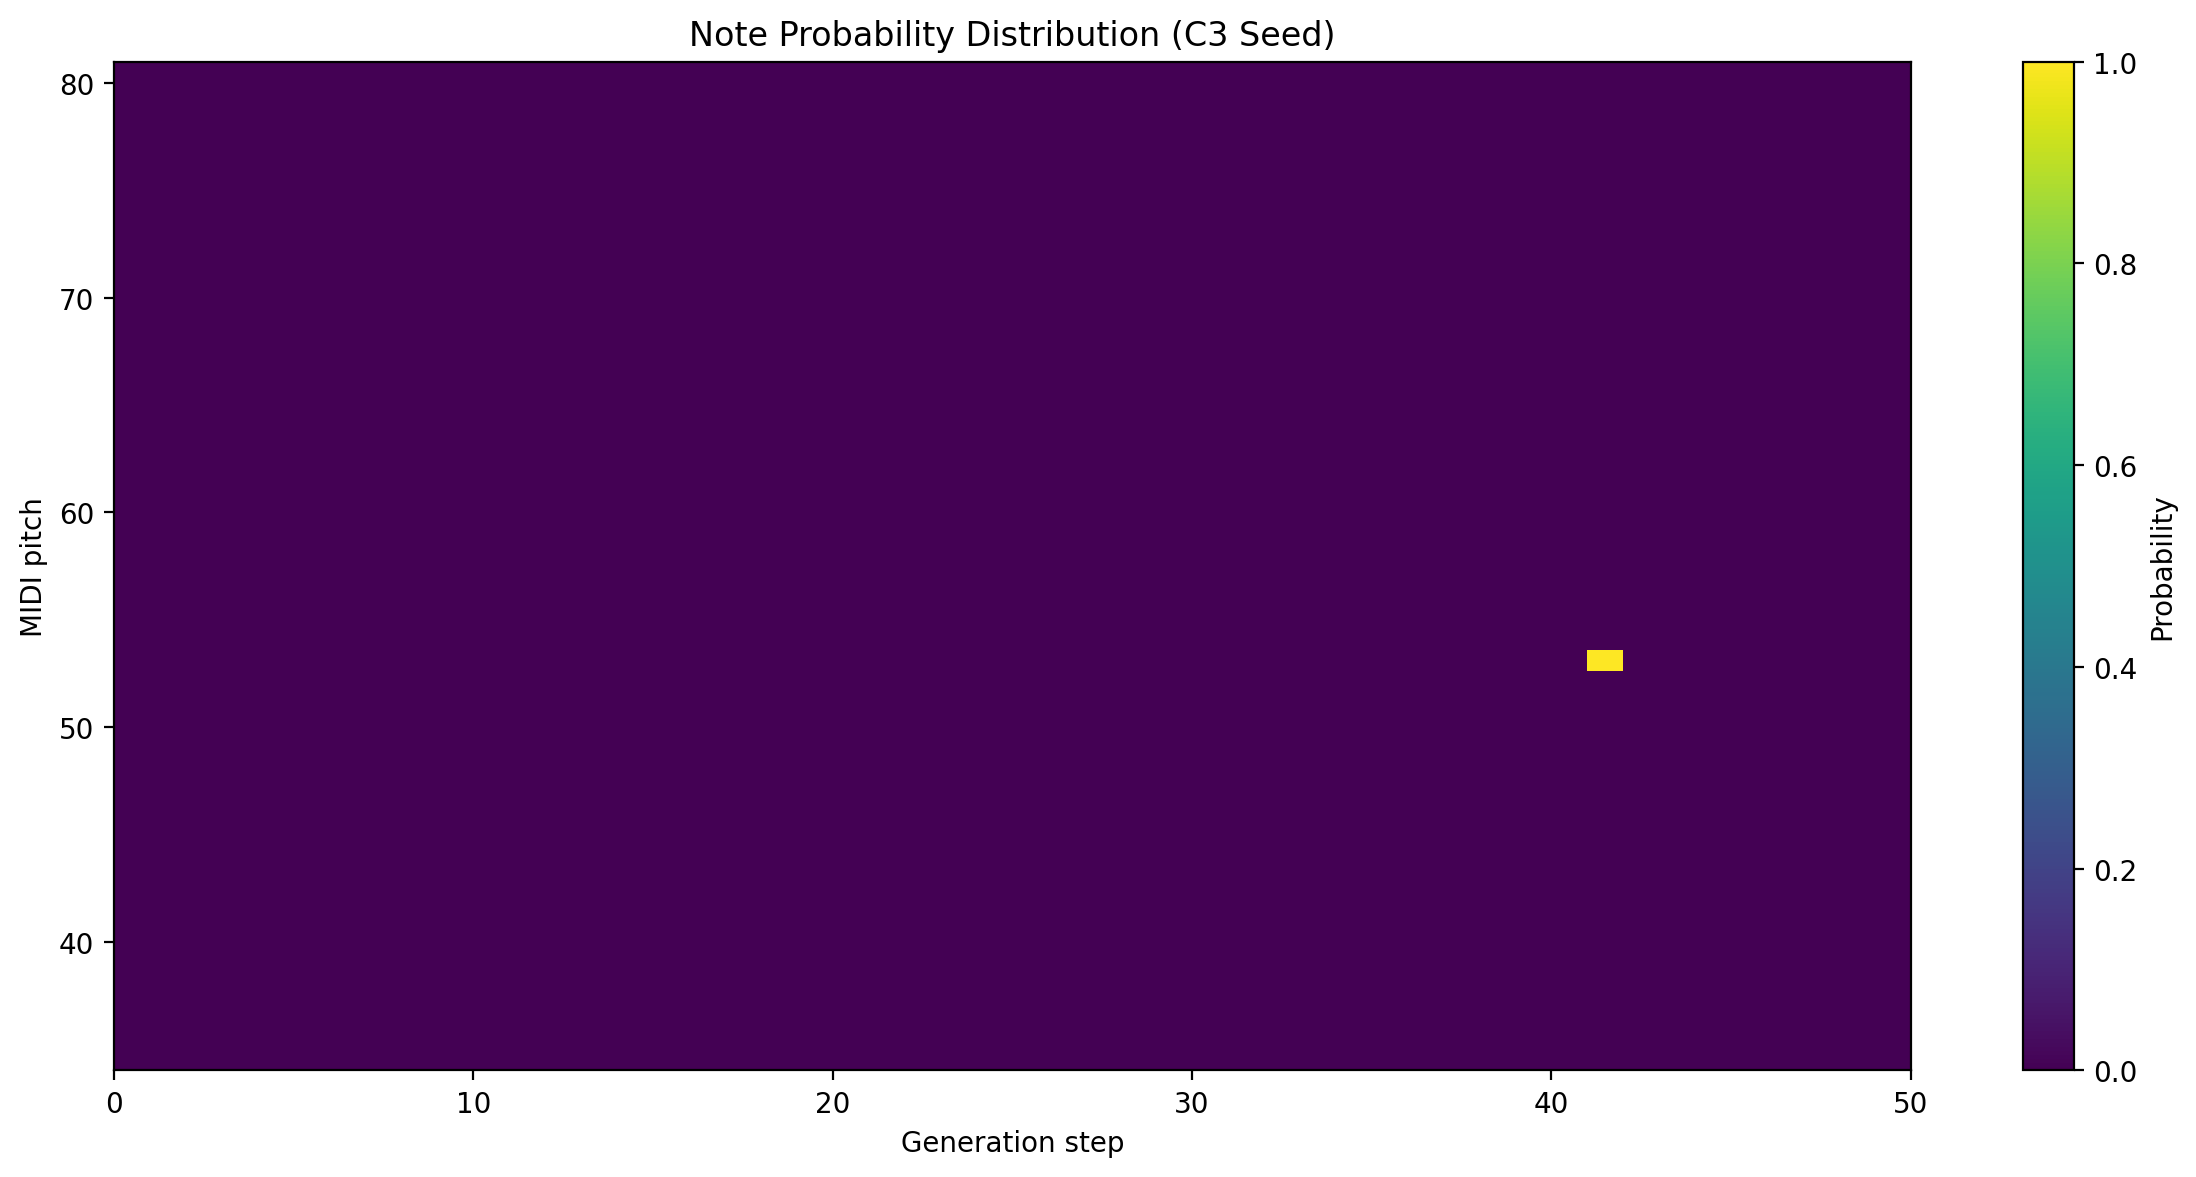

Saved figure: ./output/note_heatmap.png


In [12]:
# Note probability heatmap for the C3 seed
info_viz = info_c3

pitch_rows = []
for token in notes_vocab:
    try:
        if token not in ("", "[UNK]", "START", "rest") and not token.replace(".", "").isdigit():
            pitch_rows.append(music21.note.Note(token.split(".")[0]).pitch.midi)
    except Exception:
        continue

min_pitch = max(24, min(pitch_rows) - 2) if pitch_rows else 36
max_pitch = min(96, max(pitch_rows) + 2) if pitch_rows else 72

seq_len = len(info_viz)
grid = np.zeros((max_pitch + 1, seq_len), dtype=np.float32)

for j in range(seq_len):
    for i, prob in enumerate(info_viz[j]["note_probs"]):
        token = notes_vocab[i]
        try:
            if token in ("", "[UNK]", "START", "rest"):
                continue
            pitch = music21.note.Note(token.split(".")[0]).pitch.midi
            if 0 <= pitch <= max_pitch:
                grid[pitch, j] = prob
        except Exception:
            continue

visible = grid[min_pitch:max_pitch + 1, :]
vmax = max(float(np.max(visible)), 1e-6)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    visible,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=vmax,
    extent=[0, seq_len, min_pitch, max_pitch],
)
ax.set_title("Note Probability Distribution (C3 Seed)")
ax.set_xlabel("Generation step")
ax.set_ylabel("MIDI pitch")
fig.colorbar(im, ax=ax, label="Probability")
plt.tight_layout()
plt.savefig("./output/note_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure: ./output/note_heatmap.png")

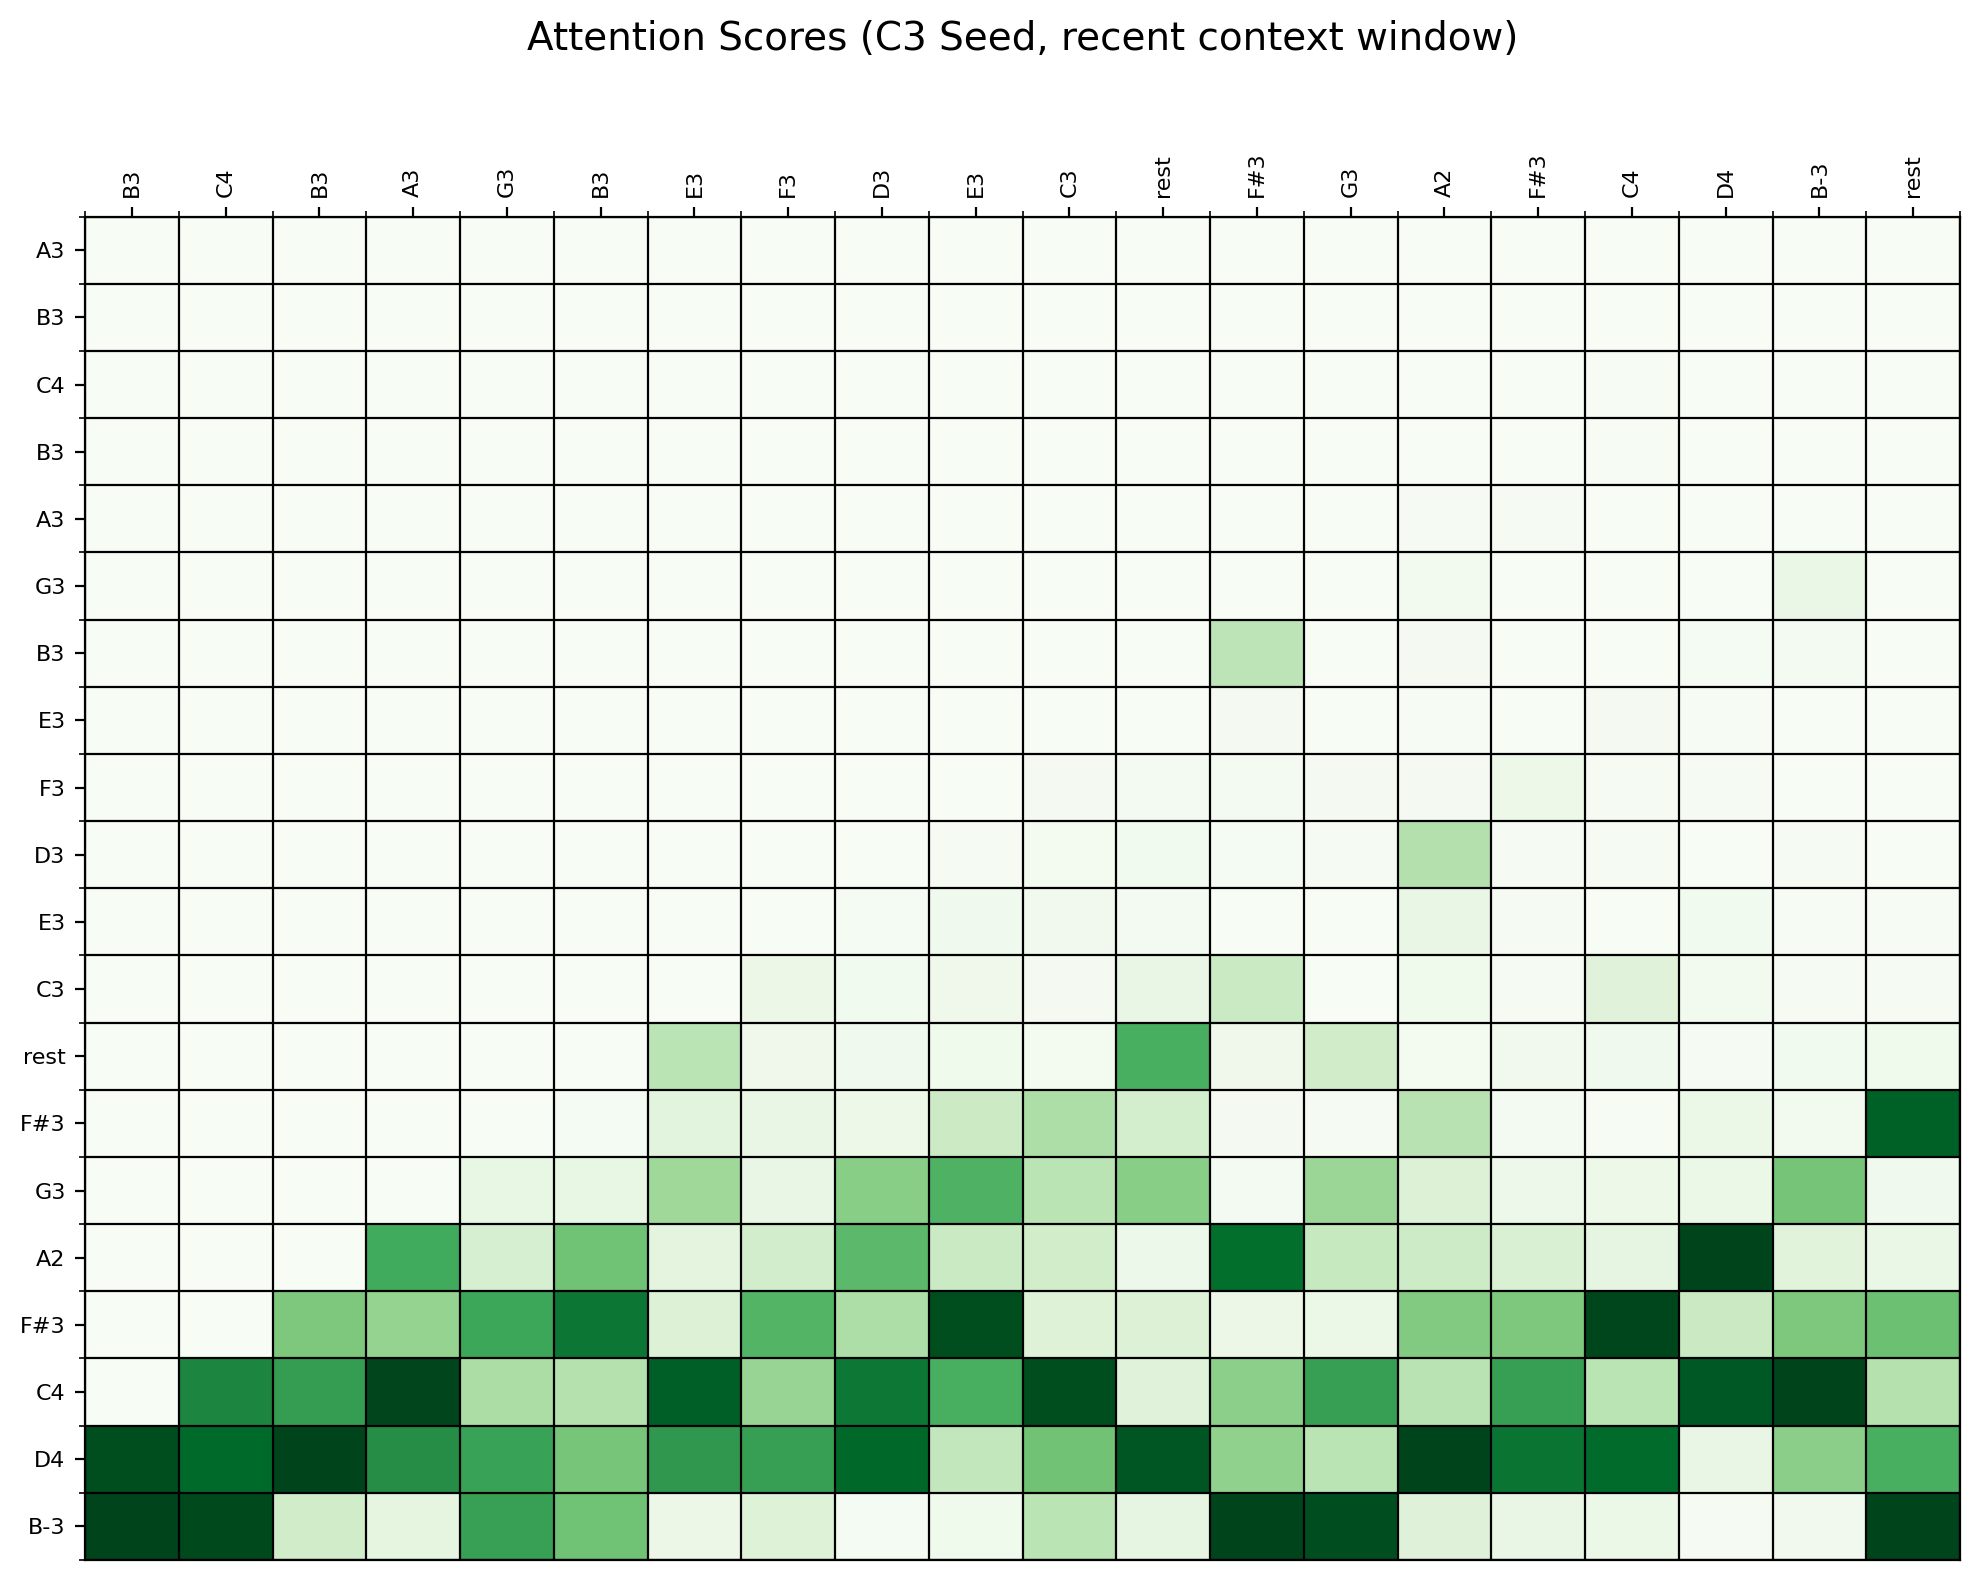

Saved figure: ./output/attention_plot.png


In [14]:
# Attention plot for the C3 seed
plot_items = [row for row in info_viz if row["atts"] is not None]

if len(plot_items) == 0:
    print("No attention tensors were captured. Generate at least two steps before plotting attention.")
else:
    plot_size = min(20, len(plot_items))

    # attention length grows with generation, so keep only a recent window
    row_size = min(
        plot_size,
        max(np.asarray(plot_items[j]["atts"]).max(axis=0).shape[0] for j in range(plot_size))
    )

    att_matrix = np.zeros((row_size, plot_size))
    pred_out = []

    for j in range(plot_size):
        atts = np.asarray(plot_items[j]["atts"]).max(axis=0).ravel()
        atts = atts[-row_size:]          # keep only recent context
        att_matrix[-len(atts):, j] = atts
        pred_out.append(plot_items[j]["chosen_note"])

    final_prompt_notes = list(plot_items[plot_size - 1]["prompt"][0])[-row_size:]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(att_matrix, cmap="Greens", interpolation="nearest", aspect="auto")
    ax.set_xticks(np.arange(plot_size))
    ax.set_yticks(np.arange(row_size))
    ax.set_xticklabels(pred_out[:plot_size], fontsize=8)
    ax.set_yticklabels(final_prompt_notes, fontsize=8)
    ax.set_xticks(np.arange(-0.5, plot_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, row_size, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.8)
    ax.xaxis.tick_top()
    plt.setp(ax.get_xticklabels(), rotation=90, ha="left", va="center", rotation_mode="anchor")
    plt.title("Attention Scores (C3 Seed, recent context window)", fontsize=14, pad=60)
    plt.tight_layout()
    plt.savefig("./output/attention_plot.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved figure: ./output/attention_plot.png")

## 12. Submission Notes

Run the next cell after generation. It creates a short comparison paragraph you can paste into your assignment.

What to submit from this notebook:
1. The notebook itself with training output and generated note-duration pairs.
2. At least one generated MIDI file such as `generated_default.mid` or `generated_C3.mid`.
3. The generated comparison paragraph saved as `./output/submission_notes.txt`.
4. Optional figures: `note_heatmap.png` and `attention_plot.png`.

In [15]:
def format_top_items(items):
    return ", ".join([f"{token} x{count}" for token, count in items]) if items else "None"


default_row = summary_df.loc[summary_df["seed_name"] == "default"].iloc[0]
c3_row = summary_df.loc[summary_df["seed_name"] == "C3"].iloc[0]
g2_row = summary_df.loc[summary_df["seed_name"] == "G2"].iloc[0]

submission_text = f"""
Example of music generated by the trained Transformer:
Using the default START/0.0 seed, the model generated {int(default_row['generated_tokens'])} note-duration pairs and saved them to ./output/generated_default.mid.
The first part of the generated sequence shows tokens such as {preview_pairs(info_default, 10)}.

Differences between my output and the original textbook-style baseline:
The default START/0.0 run acts as the baseline, while the C3/1.0 and G2/2.0 runs show how changing the seed changes the opening phrase.
Compared with the baseline, the C3 seed generated {int(c3_row['unique_notes'])} unique notes with an average duration of {c3_row['avg_duration']}, and its most common notes were {format_top_items(c3_row['most_common_note'])}.
The G2 seed generated {int(g2_row['unique_notes'])} unique notes with an average duration of {g2_row['avg_duration']}, and its most common notes were {format_top_items(g2_row['most_common_note'])}.
These differences show that the Transformer is sensitive to the initial seed and can continue the sequence with different pitch centers and rhythmic patterns, even though all runs were trained on the same Bach cello dataset.
""".strip()

print(submission_text)

with open("./output/submission_notes.txt", "w", encoding="utf-8") as f:
    f.write(submission_text)

print("\nSaved: ./output/submission_notes.txt")

Example of music generated by the trained Transformer:
Using the default START/0.0 seed, the model generated 50 note-duration pairs and saved them to ./output/generated_default.mid. 
The first part of the generated sequence shows tokens such as ['rest (2.0)', 'rest (3.0)', 'rest (1.0)', 'F3 (2.0)', 'F#3 (0.75)', 'G3.A3 (0.25)', 'G3 (0.25)', 'F#3 (0.25)', 'E3 (0.25)', 'F#3 (0.25)'].

Differences between my output and the original textbook-style baseline:
The default START/0.0 run acts as the baseline, while the C3/1.0 and G2/2.0 runs show how changing the seed changes the opening phrase. 
Compared with the baseline, the C3 seed generated 25 unique notes with an average duration of 0.84, and its most common notes were B3 x4, C4 x4, D3 x4, D4 x4, G3 x3. 
The G2 seed generated 19 unique notes with an average duration of 1.23, and its most common notes were rest x7, E-3 x5, D3 x5, D4 x4, C4 x4. 
These differences show that the Transformer is sensitive to the initial seed and can continue th